Car Price Prediction with Machine Learning

IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

LOAD DATASET

In [2]:
df = pd.read_csv("car data.csv")
print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


DATA CLEANING

In [3]:
print("\nShape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())


Shape: (301, 9)

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


Remove Car Name column

In [4]:
df.drop("Car_Name", axis=1, inplace=True)

Current Year

In [5]:
df["Car_Age"] = 2025 - df["Year"]

Remove old Year column

In [6]:
df.drop("Year", axis=1, inplace=True)

ENCODING

In [7]:
df = pd.get_dummies(
    df,
    drop_first=True
)

print(df.head())

   Selling_Price  Present_Price  Driven_kms  Owner  Car_Age  Fuel_Type_Diesel  \
0           3.35           5.59       27000      0       11             False   
1           4.75           9.54       43000      0       12              True   
2           7.25           9.85        6900      0        8             False   
3           2.85           4.15        5200      0       14             False   
4           4.60           6.87       42450      0       11              True   

   Fuel_Type_Petrol  Selling_type_Individual  Transmission_Manual  
0              True                    False                 True  
1             False                    False                 True  
2              True                    False                 True  
3              True                    False                 True  
4             False                    False                 True  


DATA VISUALIZATION

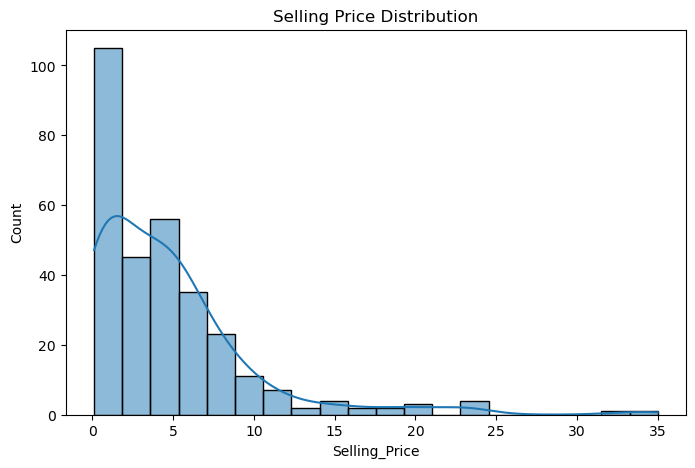

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Selling_Price"],
    bins=20,
    kde=True
)

plt.title("Selling Price Distribution")
plt.show()


CORRELATION HEATMAP

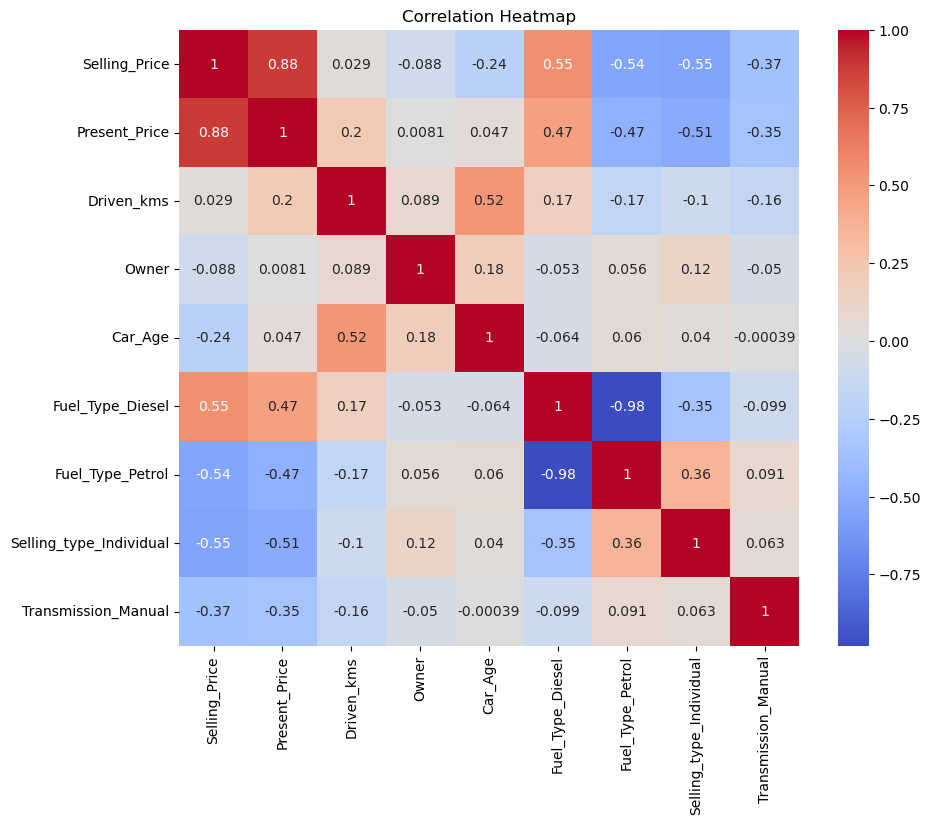

In [9]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()


TRAIN TEST SPLIT

In [10]:
X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


MODEL TRAINING

In [11]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


PREDICTION

In [12]:
y_pred = model.predict(X_test)

EVALUATION

In [13]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("\nModel Performance")
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2 Score:", round(r2,2))


Model Performance
MAE : 0.64
RMSE: 0.97
R2 Score: 0.96


ACTUAL VS PREDICTED

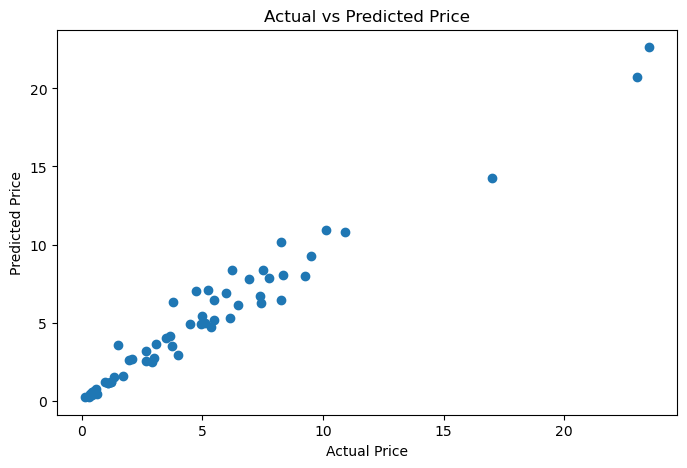

In [14]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

 SAMPLE PREDICTION

In [15]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

print("\nPredicted Price:", prediction[0])


Predicted Price: 3.862500000000004
